In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import AdaBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix,ConfusionMatrixDisplay,RocCurveDisplay,roc_curve,auc

In [4]:
df = pd.read_csv('Heart_Disease.csv')

In [5]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [8]:
df['target'].value_counts()

target
1    526
0    499
Name: count, dtype: int64

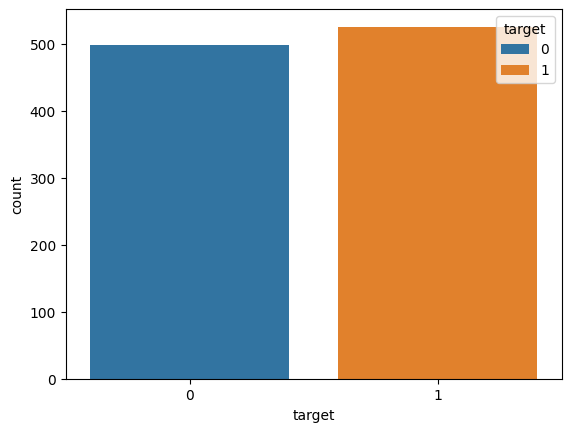

In [9]:
sns.countplot(x='target',data=df,hue='target')
plt.show()

In [10]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [15]:
x = df.drop(columns=['target'])
y = df['target']

In [16]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [17]:
model = AdaBoostClassifier(n_estimators=100, learning_rate=0.1, random_state=42)

In [18]:
model.fit(x_train,y_train)

,estimator,None
,n_estimators,100
,learning_rate,0.1
,algorithm,'deprecated'
,random_state,42


In [19]:
y_pred = model.predict(x_test)

In [23]:
acc = accuracy_score(y_test,y_pred)
cr = classification_report(y_test,y_pred)
cm = confusion_matrix(y_test,y_pred)

print(f"Accuarcy: {acc:.2f}")
print(f"Classification report:\n{cr}")
print(f"Confusion Matrix:{cm}")


Accuarcy: 0.79
Classification report:
              precision    recall  f1-score   support

           0       0.85      0.70      0.76       102
           1       0.74      0.87      0.80       103

    accuracy                           0.79       205
   macro avg       0.79      0.78      0.78       205
weighted avg       0.79      0.79      0.78       205

Confusion Matrix:[[71 31]
 [13 90]]


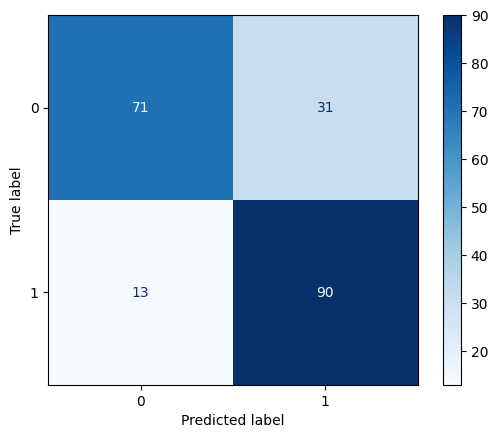

In [22]:
cmd = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
cmd.plot(cmap='Blues')
plt.show()

In [25]:
fi = model.feature_importances_
f = x.columns

In [28]:
fidf = pd.DataFrame({"features":f,"importance":fi}).sort_values('importance',ascending=False)

In [30]:
fidf.head()

,features,importance
9,oldpeak,0.273464
11,ca,0.170120
2,cp,0.159759
12,thal,0.147428
7,thalach,0.057959


C:\Users\sreek\AppData\Local\Temp\ipykernel_23436\1134436712.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance',y='features',data=fidf,palette='viridis')


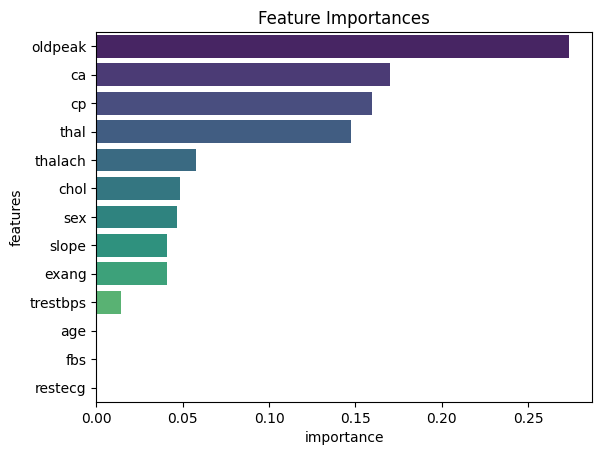

In [29]:
sns.barplot(x='importance',y='features',data=fidf,palette='viridis')
plt.title('Feature Importances')
plt.show()